# Regularização: Ridge e Lasso

Neste notebook vamos explorar o efeito da regularização sobre os coeficientes $\beta$ em regressão linear,
comparando **Ridge** (penalidade $\ell_2$) e **Lasso** (penalidade $\ell_1$), e relacionando o efeito ao
**encolhimento** (*shrinkage*) dos coeficientes.

## 1. Formulação

Dado $X \in \mathbb{R}^{n\times p}$ e $y \in \mathbb{R}^n$, ajustamos $\beta \in \mathbb{R}^p$ minimizando:

- **OLS:** $\;\min_\beta \|y - X\beta\|_2^2$
- **Ridge:** $\;\min_\beta \|y - X\beta\|_2^2 + \lambda \|\beta\|_2^2$
- **Lasso:** $\;\min_\beta \|y - X\beta\|_2^2 + \lambda \|\beta\|_1$

O parâmetro $\lambda \geq 0$ controla a intensidade da penalização.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(0)

n, p = 80, 10
X = rng.normal(size=(n, p))
beta_true = np.array([3.0, -2.0, 1.5, 0.0, 0.0, 0.8, 0.0, -1.2, 0.0, 0.0])
y = X @ beta_true + rng.normal(scale=1.0, size=n)

scaler = StandardScaler()
Xs = scaler.fit_transform(X)
ys = y - y.mean()

print('beta verdadeiro:', beta_true)

beta verdadeiro: [ 3.  -2.   1.5  0.   0.   0.8  0.  -1.2  0.   0. ]


## 2. Caminho dos coeficientes

Vamos plotar $\beta_j(\lambda)$ em função de $\lambda$ para Ridge e Lasso.

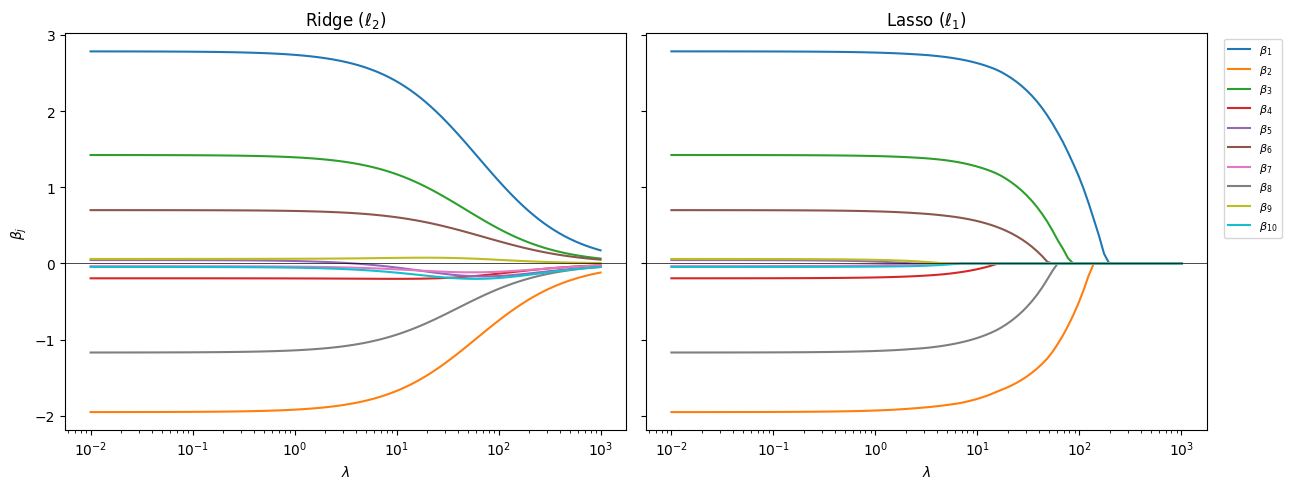

In [2]:
lambdas = np.logspace(-2, 3, 100)

betas_ridge = np.array([Ridge(alpha=lam, fit_intercept=False).fit(Xs, ys).coef_ for lam in lambdas])
betas_lasso = np.array([Lasso(alpha=lam/len(ys), fit_intercept=False, max_iter=20000).fit(Xs, ys).coef_ for lam in lambdas])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for j in range(p):
    axes[0].plot(lambdas, betas_ridge[:, j], label=f'$\\beta_{{{j+1}}}$')
    axes[1].plot(lambdas, betas_lasso[:, j], label=f'$\\beta_{{{j+1}}}$')
for ax, title in zip(axes, ['Ridge ($\\ell_2$)', 'Lasso ($\\ell_1$)']):
    ax.set_xscale('log')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('$\\lambda$')
    ax.set_title(title)
axes[0].set_ylabel('$\\beta_j$')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

**Observações:**

- No **Ridge**, todos os coeficientes diminuem suavemente em direção a zero conforme $\lambda$ aumenta, mas
  raramente são exatamente zero.
- No **Lasso**, os coeficientes vão a zero *exatamente*, um a um — o Lasso faz **seleção de variáveis**.


## 3. Efeito sobre cada $\beta$ individualmente

Comparando os coeficientes estimados por OLS, Ridge e Lasso para um $\lambda$ fixo.

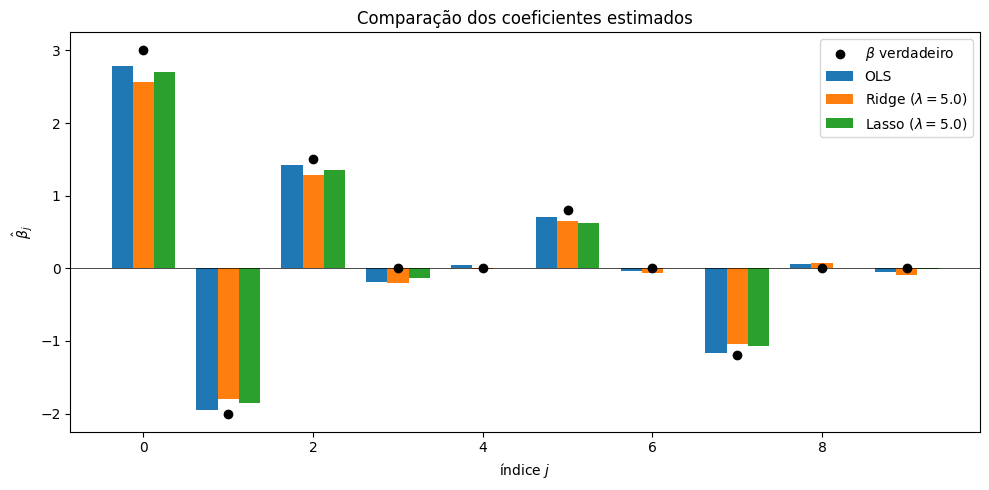

In [3]:
lam = 5.0
b_ols = LinearRegression(fit_intercept=False).fit(Xs, ys).coef_
b_ridge = Ridge(alpha=lam, fit_intercept=False).fit(Xs, ys).coef_
b_lasso = Lasso(alpha=lam/len(ys), fit_intercept=False, max_iter=20000).fit(Xs, ys).coef_

idx = np.arange(p)
w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(idx - w, b_ols,   width=w, label='OLS')
plt.bar(idx,     b_ridge, width=w, label=f'Ridge ($\\lambda={lam}$)')
plt.bar(idx + w, b_lasso, width=w, label=f'Lasso ($\\lambda={lam}$)')
plt.scatter(idx, beta_true, color='k', zorder=5, label='$\\beta$ verdadeiro')
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('índice $j$')
plt.ylabel('$\\hat\\beta_j$')
plt.title('Comparação dos coeficientes estimados')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Encolhimento (*shrinkage*)

Para o Ridge, com $X$ ortonormal ($X^\top X = I$), existe forma fechada:
$$\hat\beta_j^{\text{ridge}} = \frac{\hat\beta_j^{\text{OLS}}}{1+\lambda}$$

ou seja, **encolhimento proporcional** — todo $\beta_j$ é multiplicado pelo mesmo fator $\frac{1}{1+\lambda} < 1$.

Para o Lasso, no mesmo cenário:
$$\hat\beta_j^{\text{lasso}} = \text{sign}(\hat\beta_j^{\text{OLS}})\,\max\!\left(|\hat\beta_j^{\text{OLS}}| - \tfrac{\lambda}{2},\, 0\right)$$

que é o **soft-thresholding** — encolhimento *aditivo* que zera coeficientes pequenos.

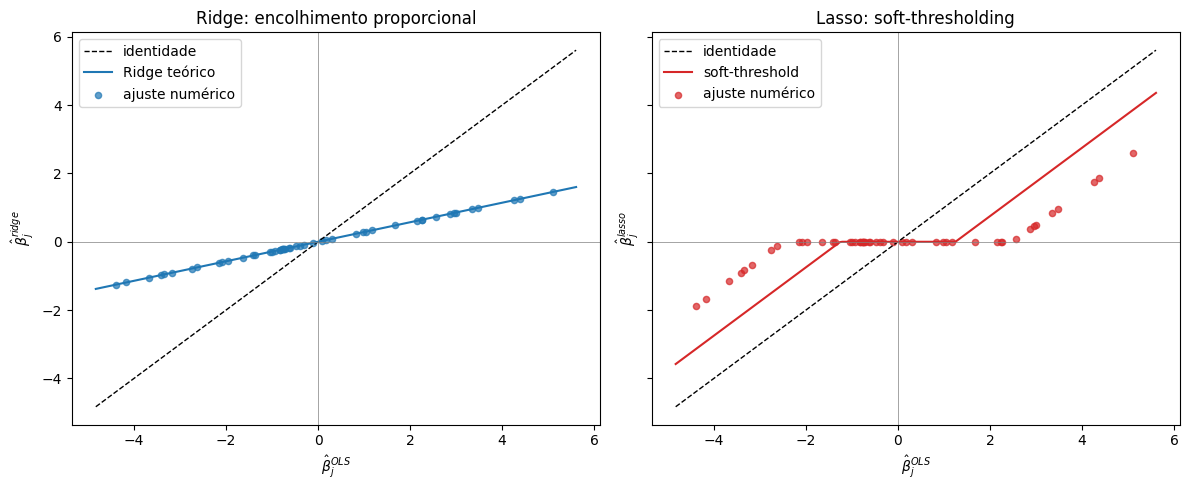

In [12]:
# Geramos um caso ortonormal para visualizar as fórmulas fechadas
Q, _ = np.linalg.qr(rng.normal(size=(200, 50)))
X_orth = Q[:, :50] * np.sqrt(200)  # colunas ortogonais
beta_o = rng.normal(scale=2.0, size=50)
y_orth = X_orth @ beta_o + rng.normal(scale=0.5, size=200)

b_ols_o = LinearRegression(fit_intercept=False).fit(X_orth, y_orth).coef_

lam_plot = 500.0
b_ridge_o = Ridge(alpha=lam_plot, fit_intercept=False).fit(X_orth, y_orth).coef_
b_lasso_o = Lasso(alpha=lam_plot/len(y_orth), fit_intercept=False, max_iter=50000).fit(X_orth, y_orth).coef_

xx = np.linspace(b_ols_o.min()*1.1, b_ols_o.max()*1.1, 200)
ridge_curve = xx / (1 + lam_plot/(X_orth[:,0] @ X_orth[:,0]))
thr = lam_plot / (2 * (X_orth[:,0] @ X_orth[:,0]))
lasso_curve = np.sign(xx) * np.maximum(np.abs(xx) - thr, 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
axes[0].plot(xx, xx, 'k--', lw=1, label='identidade')
axes[0].plot(xx, ridge_curve, 'C0', label='Ridge teórico')
axes[0].scatter(b_ols_o, b_ridge_o, s=20, alpha=0.7, label='ajuste numérico')
axes[0].set_title('Ridge: encolhimento proporcional')
axes[0].set_xlabel('$\\hat\\beta_j^{OLS}$'); axes[0].set_ylabel('$\\hat\\beta_j^{ridge}$')

axes[1].plot(xx, xx, 'k--', lw=1, label='identidade')
axes[1].plot(xx, lasso_curve, 'C3', label='soft-threshold')
axes[1].scatter(b_ols_o, b_lasso_o, s=20, alpha=0.7, color='C3', label='ajuste numérico')
axes[1].set_title('Lasso: soft-thresholding')
axes[1].set_xlabel('$\\hat\\beta_j^{OLS}$'); axes[1].set_ylabel('$\\hat\\beta_j^{lasso}$')
for ax in axes:
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.legend()
plt.tight_layout()
plt.show()

## 5. Norma dos coeficientes em função de $\lambda$

Outra forma de visualizar o encolhimento: a norma global de $\hat\beta$ diminui conforme $\lambda$ cresce.

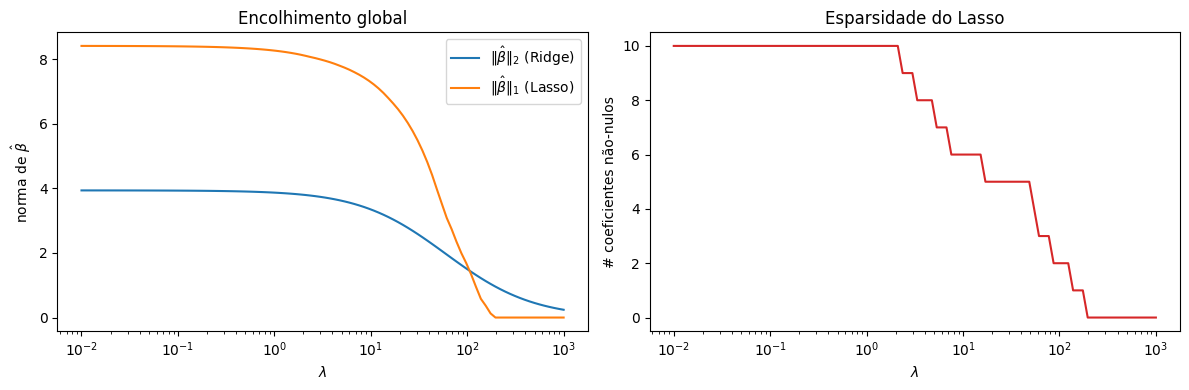

In [13]:
norm_l2_ridge = np.linalg.norm(betas_ridge, axis=1)
norm_l1_lasso = np.sum(np.abs(betas_lasso), axis=1)
n_active_lasso = np.sum(np.abs(betas_lasso) > 1e-8, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(lambdas, norm_l2_ridge, label='$\\|\\hat\\beta\\|_2$ (Ridge)')
axes[0].plot(lambdas, norm_l1_lasso, label='$\\|\\hat\\beta\\|_1$ (Lasso)')
axes[0].set_xscale('log'); axes[0].set_xlabel('$\\lambda$'); axes[0].set_ylabel('norma de $\\hat\\beta$')
axes[0].set_title('Encolhimento global'); axes[0].legend()

axes[1].plot(lambdas, n_active_lasso, color='C3')
axes[1].set_xscale('log'); axes[1].set_xlabel('$\\lambda$')
axes[1].set_ylabel('# coeficientes não-nulos')
axes[1].set_title('Esparsidade do Lasso')
plt.tight_layout()
plt.show()

## 6. Conclusões

- A regularização **encolhe** os coeficientes em direção a zero, trocando viés por menor variância.
- **Ridge** ($\ell_2$): encolhimento *proporcional* — útil quando muitas variáveis contribuem um pouco.
- **Lasso** ($\ell_1$): encolhimento *por limiar* (soft-threshold) — zera coeficientes e faz seleção de variáveis.
- O parâmetro $\lambda$ controla o trade-off: $\lambda \to 0$ recupera OLS, $\lambda \to \infty$ leva $\hat\beta \to 0$.